# Expectation-Maximization (EM) Algorithm from Scratch

# Probability Distributions Assignment

# Dataset: Galton Families

# Comparison:
# - Fathers' Heights
# - Children's Heights

# Author:
# Mildred Ebomah

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("./data/GaltonFamilies.csv")

df.head()

,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


In [21]:
df.columns

Index(['rownames', 'family', 'father', 'mother', 'midparentHeight', 'children',
       'childNum', 'gender', 'childHeight'],
      dtype='object')

In [22]:
father = df["father"].values
child = df["childHeight"].values

data = np.concatenate([father, child])

np.random.shuffle(data)

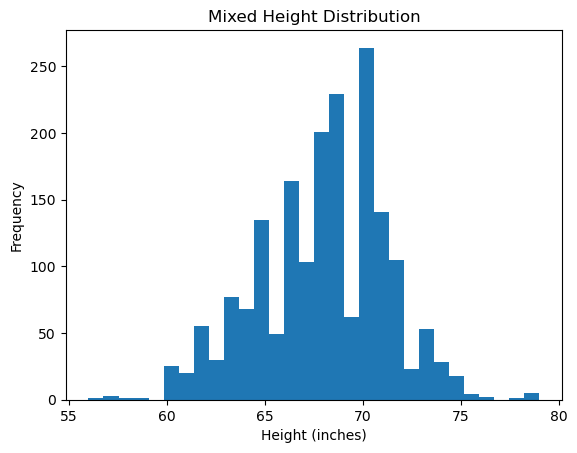

In [23]:
plt.hist(data, bins=30)

plt.title("Mixed Height Distribution")
plt.xlabel("Height (inches)")
plt.ylabel("Frequency")
plt.show()

In [24]:
def gaussian(x, mu, sigma):
    return (1 / (np.sqrt(2*np.pi)*sigma)) * np.exp(-(x-mu)**2/(2*sigma**2))

In [25]:
mu1 = np.percentile(data,30)
mu2 = np.percentile(data,70)

sigma1 = np.std(data)
sigma2 = np.std(data)

pi1 = 0.5
pi2 = 0.5

In [26]:
def expectation(data, mu1, mu2, sigma1, sigma2, pi1, pi2):

    p1 = pi1 * gaussian(data, mu1, sigma1)
    p2 = pi2 * gaussian(data, mu2, sigma2)

    gamma1 = p1/(p1+p2)
    gamma2 = p2/(p1+p2)

    return gamma1, gamma2

In [27]:
def maximization(data, gamma1, gamma2):

    N1 = gamma1.sum()
    N2 = gamma2.sum()

    mu1 = (gamma1*data).sum()/N1
    mu2 = (gamma2*data).sum()/N2

    sigma1 = np.sqrt((gamma1*((data-mu1)**2)).sum()/N1)
    sigma2 = np.sqrt((gamma2*((data-mu2)**2)).sum()/N2)

    pi1 = N1/len(data)
    pi2 = N2/len(data)

    return mu1,mu2,sigma1,sigma2,pi1,pi2

In [28]:
def log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2):

    likelihood = np.log(
        pi1*gaussian(data,mu1,sigma1) +
        pi2*gaussian(data,mu2,sigma2)
    )

    return likelihood.sum()

In [29]:
history=[]

for i in range(20):

    gamma1,gamma2 = expectation(data,mu1,mu2,sigma1,sigma2,pi1,pi2)

    mu1,mu2,sigma1,sigma2,pi1,pi2 = maximization(data,gamma1,gamma2)

    ll = log_likelihood(data,mu1,mu2,sigma1,sigma2,pi1,pi2)

    history.append([i,mu1,mu2,sigma1,sigma2,pi1,pi2,ll])

In [30]:
history = pd.DataFrame(history,
columns=[
"Iteration",
"mu1",
"mu2",
"sigma1",
"sigma2",
"pi1",
"pi2",
"LogLikelihood"
])

history.head(3)

,Iteration,mu1,mu2,sigma1,sigma2,pi1,pi2,LogLikelihood
0,0,66.402975,69.518936,3.114996,2.717714,0.496610,0.503390,-4873.516481
1,1,66.373024,69.529962,3.199178,2.599024,0.493656,0.506344,-4869.372053
2,2,66.343195,69.549662,3.238429,2.522989,0.492175,0.507825,-4867.634070


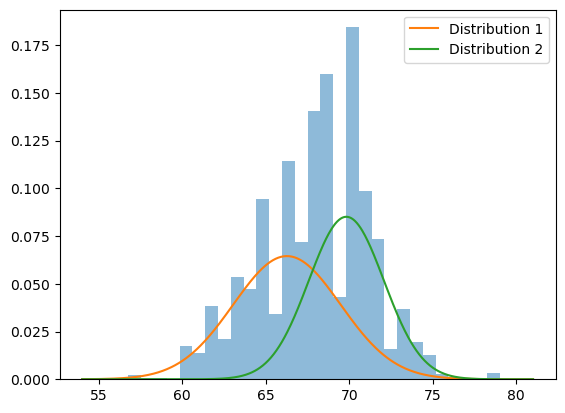

In [31]:
x=np.linspace(data.min()-2,data.max()+2,500)

plt.hist(data,bins=30,density=True,alpha=0.5)

plt.plot(x,pi1*gaussian(x,mu1,sigma1),label="Distribution 1")

plt.plot(x,pi2*gaussian(x,mu2,sigma2),label="Distribution 2")

plt.legend()

plt.show()

In [32]:
##Example

Height = 71

In [33]:
height=71

p1=pi1*gaussian(height,mu1,sigma1)
p2=pi2*gaussian(height,mu2,sigma2)

child=p1/(p1+p2)
father=p2/(p1+p2)

print("Probability Child =",child)
print("Probability Father =",father)

Probability Child = 0.22668527249794365
Probability Father = 0.7733147275020563


In [34]:
##Example

Height = 65

In [35]:
height=65

p1=pi1*gaussian(height,mu1,sigma1)
p2=pi2*gaussian(height,mu2,sigma2)

child=p1/(p1+p2)
father=p2/(p1+p2)

print("Probability Child =",child)
print("Probability Father =",father)

Probability Child = 0.8741145422233424
Probability Father = 0.12588545777665755
